# 2.3.1: Apparel Classification — MobileNetV2

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## Load & Preprocess Images

In [3]:
IMG_SIZE = 224
DATA_DIR = 'data/apparel/dataset'
classes = sorted(os.listdir(DATA_DIR))
print(f'Classes: {classes}')

images = []
labels = []

for idx, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        img = cv2.imread(fpath)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(idx)

X = np.array(images, dtype='float32') / 255.0
y = np.array(labels)
print(f'Total images: {X.shape[0]}, Shape: {X.shape}')
print(f'Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}')

Classes: ['dress', 'pants', 'shirt', 'shoes']
Total images: 800, Shape: (800, 224, 224, 3)
Label distribution: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200)}


## Train/Val/Test Split (80/10/10)

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

Train: 640, Val: 80, Test: 80


## Build Model

In [5]:
base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Train

In [6]:
early_stop = EarlyStopping(patience=2, monitor='val_loss', restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8359 - loss: 0.4703 - val_accuracy: 0.9250 - val_loss: 0.3284
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 843ms/step - accuracy: 0.9828 - loss: 0.0482 - val_accuracy: 0.9500 - val_loss: 0.2467
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 789ms/step - accuracy: 0.9859 - loss: 0.0349 - val_accuracy: 0.9375 - val_loss: 0.2185
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 839ms/step - accuracy: 0.9922 - loss: 0.0202 - val_accuracy: 0.9250 - val_loss: 0.2361
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 830ms/step - accuracy: 0.9859 - loss: 0.0340 - val_accuracy: 0.9250 - val_loss: 0.2688


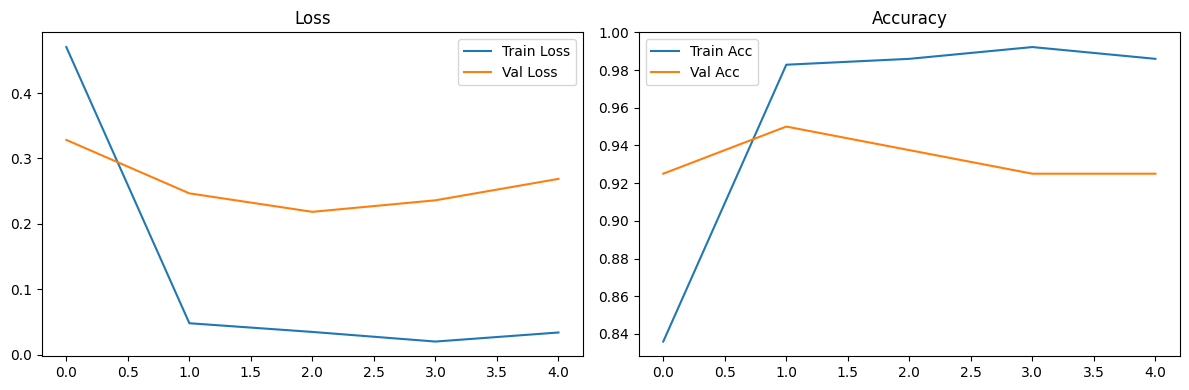

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluation

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

y_pred = np.argmax(model.predict(X_test), axis=1)
print()
print(classification_report(y_test, y_pred, target_names=classes))

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 523ms/step - accuracy: 0.9750 - loss: 0.1112
Test Loss: 0.1112, Test Accuracy: 0.9750


3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step  

              precision    recall  f1-score   support

       dress       1.00      1.00      1.00        20
       pants       0.95      0.95      0.95        20
       shirt       1.00      0.95      0.97        20
       shoes       0.95      1.00      0.98        20

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



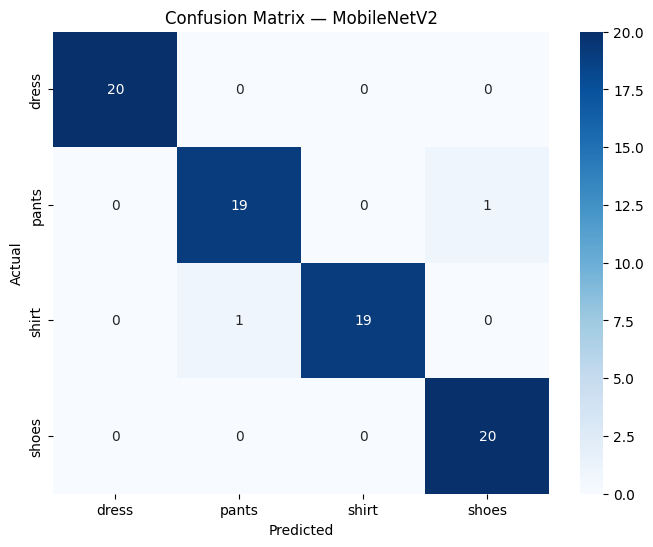

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — MobileNetV2')
plt.show()

Misclassified: 2 / 80


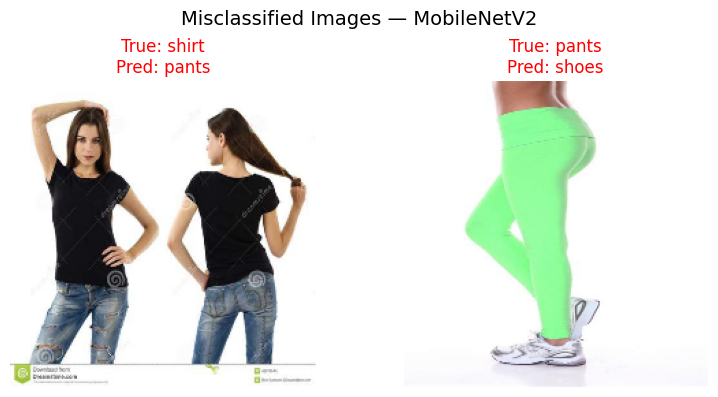

In [10]:
# Show all misclassified images
miss_idx = np.where(y_pred != y_test)[0]
n_miss = len(miss_idx)
print(f'Misclassified: {n_miss} / {len(y_test)}')

if n_miss > 0:
    cols = min(n_miss, 5)
    rows = (n_miss + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if n_miss == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for i, idx in enumerate(miss_idx):
        axes[i].imshow(X_test[idx])
        axes[i].set_title(f'True: {classes[y_test[idx]]}\nPred: {classes[y_pred[idx]]}', fontsize=12, color='red')
        axes[i].axis('off')

    for i in range(n_miss, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Misclassified Images — MobileNetV2', fontsize=14)
    plt.tight_layout()
    plt.show()